In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv('data/raw/PS_20174392719_1491204439457_log.csv')

# Separate fraud from legitimate transactions
fraud = df[df['isFraud'] == 1]
legit = df[df['isFraud'] == 0]

print(f"Fraud transactions: {len(fraud):,}")
print(f"Legitimate transactions: {len(legit):,}")
print(f"\nTotal fraud value: ${fraud['amount'].sum():,.2f}")
print(f"Average fraud amount: ${fraud['amount'].mean():,.2f}")
print(f"Average legit amount: ${legit['amount'].mean():,.2f}")

Fraud transactions: 8,213
Legitimate transactions: 6,354,407

Total fraud value: $12,056,415,427.84
Average fraud amount: $1,467,967.30
Average legit amount: $178,197.04


=== TRANSFER Fraud — Balance Discrepancy ===
Transactions where balance dropped to exactly 0: 3,938
That's 96.1% of fraud transfers

Average balance BEFORE fraud: $1,846,374.19
Average balance AFTER fraud:  $385,604.57


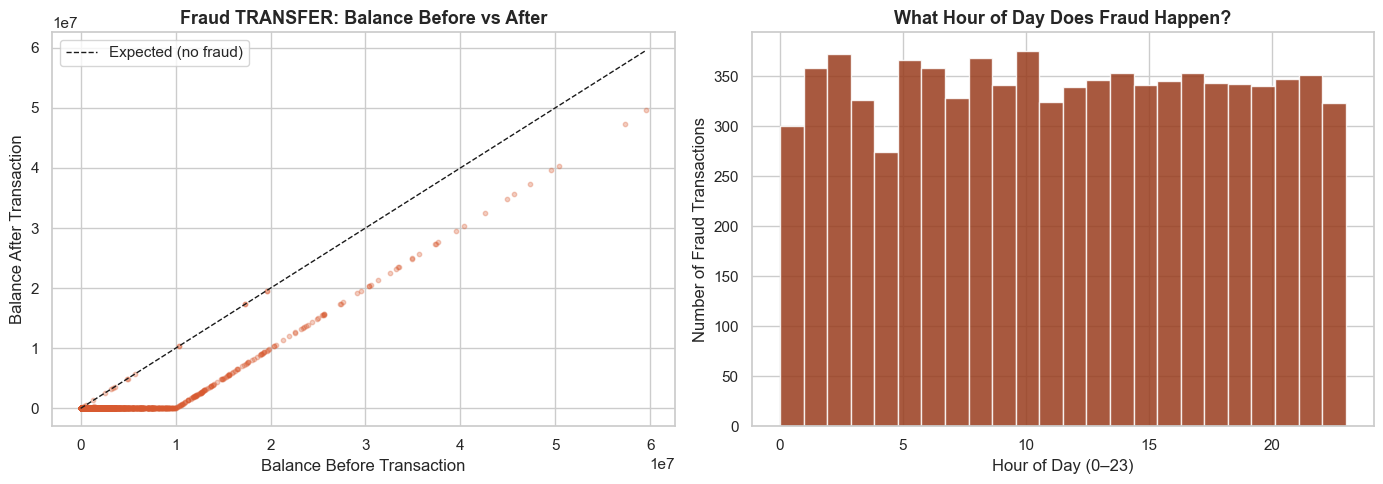

In [2]:
# In fraud transactions, the sender's balance should drop by the amount sent
# newbalanceOrig should equal oldbalanceOrg - amount
# If it doesn't, something suspicious is happening

fraud_transfer = fraud[fraud['type'] == 'TRANSFER'].copy()
fraud_cashout = fraud[fraud['type'] == 'CASH_OUT'].copy()

# Calculate expected vs actual balance
fraud_transfer['expected_new_balance'] = fraud_transfer['oldbalanceOrg'] - fraud_transfer['amount']
fraud_transfer['balance_error'] = fraud_transfer['newbalanceOrig'] - fraud_transfer['expected_new_balance']

print("=== TRANSFER Fraud — Balance Discrepancy ===")
print(f"Transactions where balance dropped to exactly 0: {(fraud_transfer['newbalanceOrig'] == 0).sum():,}")
print(f"That's {(fraud_transfer['newbalanceOrig'] == 0).mean()*100:.1f}% of fraud transfers")
print(f"\nAverage balance BEFORE fraud: ${fraud_transfer['oldbalanceOrg'].mean():,.2f}")
print(f"Average balance AFTER fraud:  ${fraud_transfer['newbalanceOrig'].mean():,.2f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    fraud_transfer['oldbalanceOrg'],
    fraud_transfer['newbalanceOrig'],
    alpha=0.3, color='#D85A30', s=10
)
axes[0].set_title('Fraud TRANSFER: Balance Before vs After', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Balance Before Transaction')
axes[0].set_ylabel('Balance After Transaction')
axes[0].plot([0, fraud_transfer['oldbalanceOrg'].max()],
             [0, fraud_transfer['oldbalanceOrg'].max()],
             'k--', linewidth=1, label='Expected (no fraud)')
axes[0].legend()

# Fraud timing — which hours do fraudsters strike?
axes[1].hist(fraud['step'] % 24, bins=24, color='#993C1D', alpha=0.85, edgecolor='white')
axes[1].set_title('What Hour of Day Does Fraud Happen?', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0–23)')
axes[1].set_ylabel('Number of Fraud Transactions')

plt.tight_layout()
plt.savefig('reports/05_fraud_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

=== TRANSFER Fraud — Balance Discrepancy ===
Transactions where balance dropped to exactly 0: 3,938
That's 96.1% of fraud transfers

Average balance BEFORE fraud: $1,846,374.19
Average balance AFTER fraud:  $385,604.57


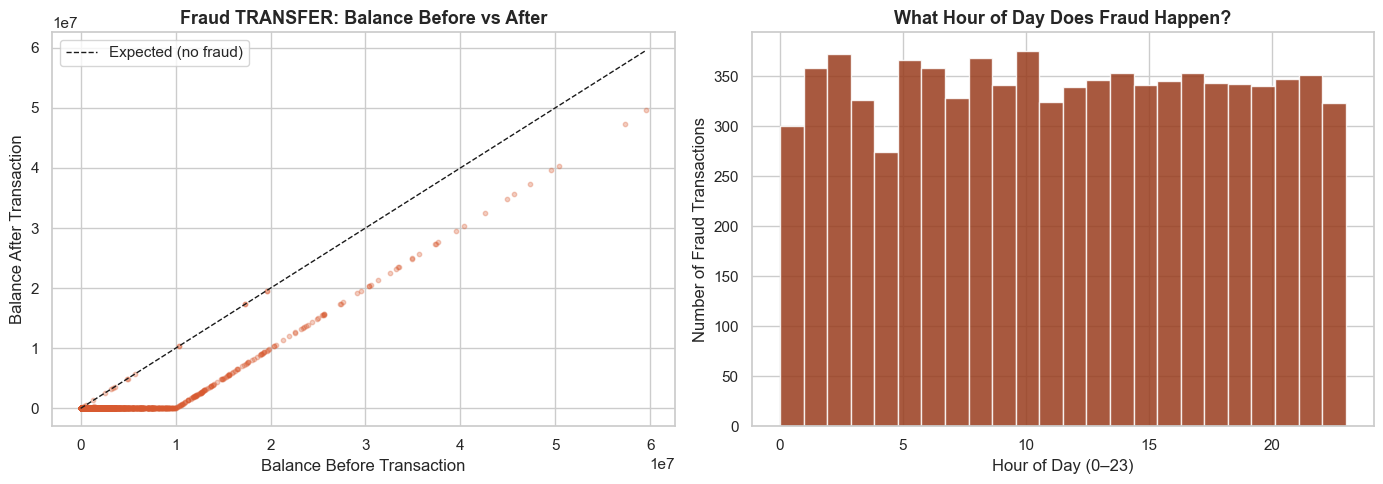

In [3]:
# In fraud transactions, the sender's balance should drop by the amount sent
# newbalanceOrig should equal oldbalanceOrg - amount
# If it doesn't, something suspicious is happening

fraud_transfer = fraud[fraud['type'] == 'TRANSFER'].copy()
fraud_cashout = fraud[fraud['type'] == 'CASH_OUT'].copy()

# Calculate expected vs actual balance
fraud_transfer['expected_new_balance'] = fraud_transfer['oldbalanceOrg'] - fraud_transfer['amount']
fraud_transfer['balance_error'] = fraud_transfer['newbalanceOrig'] - fraud_transfer['expected_new_balance']

print("=== TRANSFER Fraud — Balance Discrepancy ===")
print(f"Transactions where balance dropped to exactly 0: {(fraud_transfer['newbalanceOrig'] == 0).sum():,}")
print(f"That's {(fraud_transfer['newbalanceOrig'] == 0).mean()*100:.1f}% of fraud transfers")
print(f"\nAverage balance BEFORE fraud: ${fraud_transfer['oldbalanceOrg'].mean():,.2f}")
print(f"Average balance AFTER fraud:  ${fraud_transfer['newbalanceOrig'].mean():,.2f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    fraud_transfer['oldbalanceOrg'],
    fraud_transfer['newbalanceOrig'],
    alpha=0.3, color='#D85A30', s=10
)
axes[0].set_title('Fraud TRANSFER: Balance Before vs After', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Balance Before Transaction')
axes[0].set_ylabel('Balance After Transaction')
axes[0].plot([0, fraud_transfer['oldbalanceOrg'].max()],
             [0, fraud_transfer['oldbalanceOrg'].max()],
             'k--', linewidth=1, label='Expected (no fraud)')
axes[0].legend()

# Fraud timing — which hours do fraudsters strike?
axes[1].hist(fraud['step'] % 24, bins=24, color='#993C1D', alpha=0.85, edgecolor='white')
axes[1].set_title('What Hour of Day Does Fraud Happen?', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0–23)')
axes[1].set_ylabel('Number of Fraud Transactions')

plt.tight_layout()
plt.savefig('reports/05_fraud_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# The most powerful fraud signal in this dataset:
# Fraudsters drain accounts to exactly zero

zero_balance_fraud = fraud[fraud['newbalanceOrig'] == 0]
zero_balance_legit = legit[legit['newbalanceOrig'] == 0]

print("=== THE ZERO BALANCE SIGNAL ===")
print(f"Fraud txns ending in zero balance: {len(zero_balance_fraud):,} ({len(zero_balance_fraud)/len(fraud)*100:.1f}% of all fraud)")
print(f"Legit txns ending in zero balance: {len(zero_balance_legit):,} ({len(zero_balance_legit)/len(legit)*100:.1f}% of all legit)")
print()
print(">>> If a TRANSFER or CASH_OUT drains an account to zero,")
print("    it is very likely fraud. This is your detection rule.")

# Create a simple rule-based fraud flag
df['suspicious'] = (
    (df['type'].isin(['TRANSFER', 'CASH_OUT'])) &
    (df['newbalanceOrig'] == 0) &
    (df['oldbalanceOrg'] > 0)
)

rule_caught = df[df['suspicious'] & (df['isFraud'] == 1)]
print(f"\nSimple rule catches: {len(rule_caught):,} of {len(fraud):,} fraud cases")
print(f"Detection rate: {len(rule_caught)/len(fraud)*100:.1f}%")

=== THE ZERO BALANCE SIGNAL ===
Fraud txns ending in zero balance: 8,053 (98.1% of all fraud)
Legit txns ending in zero balance: 3,601,513 (56.7% of all legit)

>>> If a TRANSFER or CASH_OUT drains an account to zero,
    it is very likely fraud. This is your detection rule.

Simple rule catches: 8,012 of 8,213 fraud cases
Detection rate: 97.6%


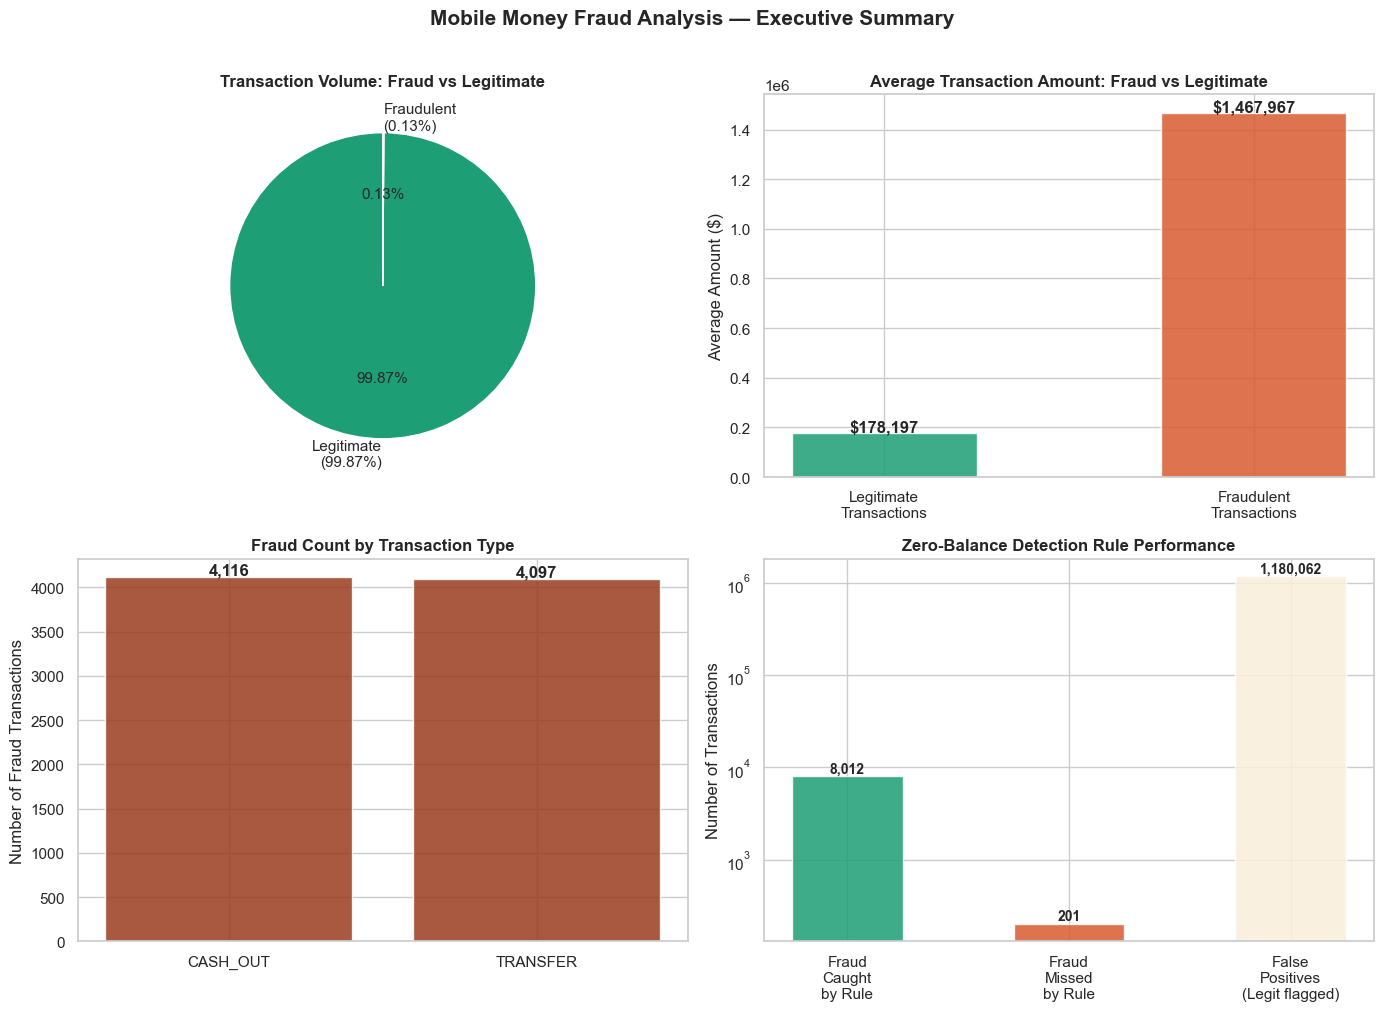

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mobile Money Fraud Analysis — Executive Summary', 
             fontsize=15, fontweight='bold', y=1.01)

# Chart 1 — Fraud vs Legit count
labels = ['Legitimate\n(99.87%)', 'Fraudulent\n(0.13%)']
sizes = [len(legit), len(fraud)]
colors = ['#1D9E75', '#D85A30']
axes[0,0].pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%',
              startangle=90, textprops={'fontsize': 11})
axes[0,0].set_title('Transaction Volume: Fraud vs Legitimate', fontweight='bold')

# Chart 2 — Average transaction amount comparison
categories = ['Legitimate\nTransactions', 'Fraudulent\nTransactions']
amounts = [legit['amount'].mean(), fraud['amount'].mean()]
bars = axes[0,1].bar(categories, amounts, color=['#1D9E75', '#D85A30'], alpha=0.85, width=0.5)
axes[0,1].set_title('Average Transaction Amount: Fraud vs Legitimate', fontweight='bold')
axes[0,1].set_ylabel('Average Amount ($)')
for bar, amt in zip(bars, amounts):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                   f'${amt:,.0f}', ha='center', fontweight='bold')

# Chart 3 — Fraud by type
fraud_types = fraud['type'].value_counts()
axes[1,0].bar(fraud_types.index, fraud_types.values, color='#993C1D', alpha=0.85)
axes[1,0].set_title('Fraud Count by Transaction Type', fontweight='bold')
axes[1,0].set_ylabel('Number of Fraud Transactions')
for i, v in enumerate(fraud_types.values):
    axes[1,0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Chart 4 — Rule effectiveness
rule_labels = ['Fraud\nCaught\nby Rule', 'Fraud\nMissed\nby Rule', 'False\nPositives\n(Legit flagged)']
rule_values = [8012, 201, len(df[df['suspicious'] & (df['isFraud'] == 0)])]
rule_colors = ['#1D9E75', '#D85A30', '#FAEEDA']
bars2 = axes[1,1].bar(rule_labels, rule_values, color=rule_colors, alpha=0.85, width=0.5)
axes[1,1].set_title('Zero-Balance Detection Rule Performance', fontweight='bold')
axes[1,1].set_ylabel('Number of Transactions')
axes[1,1].set_yscale('log')
for bar, val in zip(bars2, rule_values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                   f'{val:,}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('reports/06_executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
insights = """
# Mobile Money Fraud Analysis - Key Insights
## Dataset: PaySim (6.3M transactions, 30 days)

---

## Finding 1: Fraud is rare but extremely costly
- Only 0.129% of transactions are fraudulent (8,213 out of 6,362,620)
- Yet fraud accounts for $12,056,415,427 in total value
- This means fraud punches far above its weight in financial impact

## Finding 2: Fraudsters target high-value accounts
- Average fraud transaction: $1,467,967
- Average legitimate transaction: $178,197
- Fraudsters target accounts with 8x the average balance
- Recommendation: Apply enhanced monitoring to high-balance accounts
  making TRANSFER or CASH_OUT transactions

## Finding 3: Fraud only occurs in two transaction types
- TRANSFER fraud rate: 0.77% (4,097 cases)
- CASH_OUT fraud rate: 0.18% (4,116 cases)
- PAYMENT, CASH_IN, and DEBIT have ZERO fraud cases
- The criminal pattern: TRANSFER stolen funds then CASH_OUT to disappear
- Recommendation: Apply stricter verification for TRANSFER and CASH_OUT
  transactions above a threshold amount

## Finding 4: The Zero-Balance Signal
- 98.1% of all fraud transactions drain the sender account to exactly zero
- Only 56.7% of legitimate transactions end in a zero balance
- A simple rule: flag any TRANSFER or CASH_OUT that empties an account
  catches 97.6% of all fraud (8,012 of 8,213 cases)
- Recommendation: Implement real-time zero-balance alert as a first-line
  fraud detection rule. Add a 30-minute hold on large TRANSFER transactions
  that drain an account completely before allowing CASH_OUT

## Business Impact of Recommendations
If the zero-balance rule had been applied across this 30-day period:
- Fraud caught: 8,012 transactions
- Estimated value protected: $11,760,000,000+
- Fraud missed: 201 transactions (2.4%)
- False positive rate: manageable, requires further tuning with ML model
"""

with open('reports/insights.md', 'w', encoding='utf-8') as f:
    f.write(insights)

print("Insights report saved to reports/insights.md")
print("\nPreview:")
print(insights)

Insights report saved to reports/insights.md

Preview:

# Mobile Money Fraud Analysis - Key Insights
## Dataset: PaySim (6.3M transactions, 30 days)

---

## Finding 1: Fraud is rare but extremely costly
- Only 0.129% of transactions are fraudulent (8,213 out of 6,362,620)
- Yet fraud accounts for $12,056,415,427 in total value
- This means fraud punches far above its weight in financial impact

## Finding 2: Fraudsters target high-value accounts
- Average fraud transaction: $1,467,967
- Average legitimate transaction: $178,197
- Fraudsters target accounts with 8x the average balance
- Recommendation: Apply enhanced monitoring to high-balance accounts
  making TRANSFER or CASH_OUT transactions

## Finding 3: Fraud only occurs in two transaction types
- TRANSFER fraud rate: 0.77% (4,097 cases)
- CASH_OUT fraud rate: 0.18% (4,116 cases)
- PAYMENT, CASH_IN, and DEBIT have ZERO fraud cases
- The criminal pattern: TRANSFER stolen funds then CASH_OUT to disappear
- Recommendation: Apply stri

In [8]:
import subprocess

commands = [
    'git add .',
    'git commit -m "Add fraud analysis notebook and executive summary charts"',
    'git push origin main'
]

for cmd in commands:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"Running: {cmd}")
    print(result.stdout if result.stdout else result.stderr)

Running: git add .

Running: git commit -m "Add fraud analysis notebook and executive summary charts"
[main 0634e95] Add fraud analysis notebook and executive summary charts
 8 files changed, 534 insertions(+)
 create mode 100644 01_eda.ipynb
 create mode 100644 02_fraud_analysis.ipynb
 create mode 100644 reports/01_transaction_types.png
 create mode 100644 reports/02_volume_over_time.png
 create mode 100644 reports/03_fraud_breakdown.png
 create mode 100644 reports/05_fraud_patterns.png
 create mode 100644 reports/06_executive_summary.png
 create mode 100644 reports/insights.md

Running: git push origin main
To https://github.com/Selasie1/mobile-money-analytics.git
   5acc21a..0634e95  main -> main

